In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel("OneDrive/dawoodpython/churn_data.xlsx")
df.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.isnull().sum()

customerID          0
tenure              0
PhoneService        0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.describe()

,tenure,MonthlyCharges
count,7042.000000,7042.000000
mean,32.366373,64.755886
std,24.557955,30.088238
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7042 entries, 0 to 7041
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7042 non-null   object 
 1   tenure            7042 non-null   int64  
 2   PhoneService      7042 non-null   object 
 3   Contract          7042 non-null   object 
 4   PaperlessBilling  7042 non-null   object 
 5   PaymentMethod     7042 non-null   object 
 6   MonthlyCharges    7042 non-null   float64
 7   TotalCharges      7042 non-null   object 
 8   Churn             7042 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 495.3+ KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
numerical_cols=df.select_dtypes(include=['int64','float64']).columns
numerical_cols  

Index(['tenure', 'MonthlyCharges'], dtype='object')

Skewness is  0.23983719787783483
Histogram of the tenure


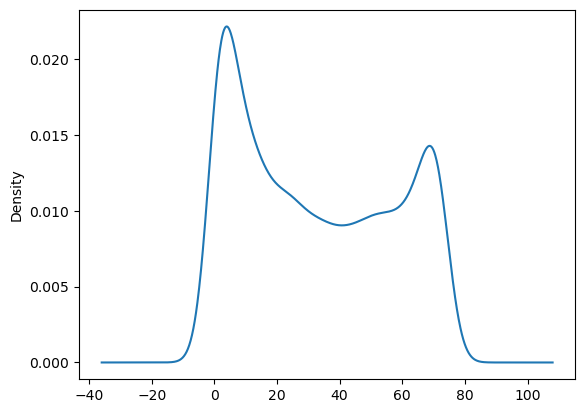

Skewness is  -0.22037298962125138
Histogram of the MonthlyCharges


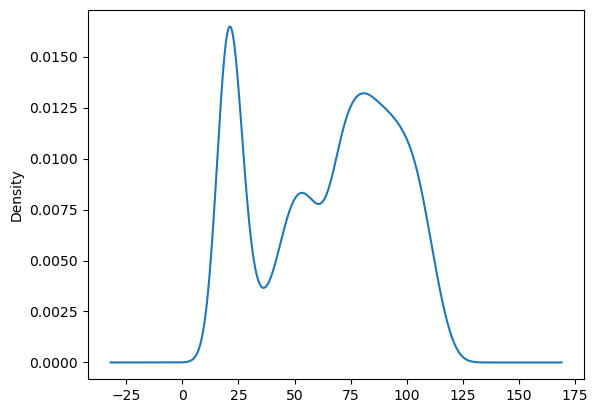

In [8]:
for col in numerical_cols:
    print("Skewness is ",df[col].skew())
    df[col].plot(kind='kde')
    print(f"Histogram of the {col}")
    plt.show()

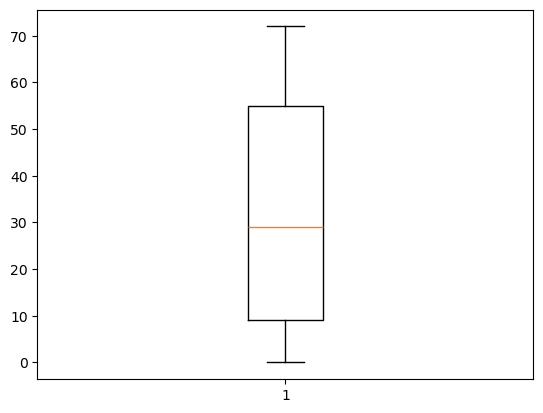

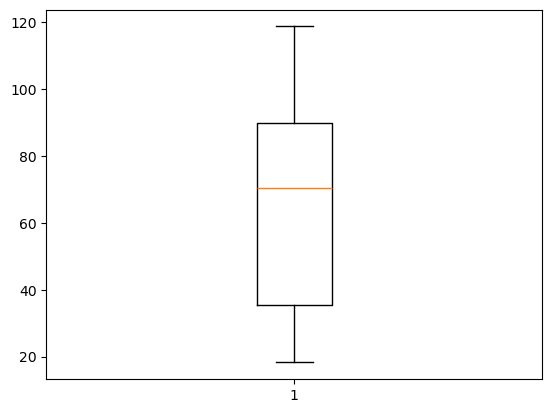

In [9]:
for col in numerical_cols:
    plt.boxplot(df[col].dropna())
    plt.show()

In [10]:
#here no outliers are persent data is skewed normally
categorical_columns=df.select_dtypes(include=['object']).columns
categorical_columns

Index(['customerID', 'PhoneService', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
for col in categorical_columns:
    print(df[col].value_counts())
    print( "________")

customerID
8361-LTMKD    1
7590-VHVEG    1
2823-LKABH    1
7398-LXGYX    1
1035-IPQPU    1
             ..
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
3668-QPYBK    1
Name: count, Length: 7042, dtype: int64
________
PhoneService
Yes    6360
No      682
Name: count, dtype: int64
________
Contract
Month-to-month    3875
Two year          1694
One year          1473
Name: count, dtype: int64
________
PaperlessBilling
Yes    4170
No     2872
Name: count, dtype: int64
________
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1543
Credit card (automatic)      1522
Name: count, dtype: int64
________
TotalCharges
20.2      11
          11
19.75      9
19.65      8
19.9       8
          ..
1419.4     1
1990.5     1
7362.9     1
346.45     1
306.6      1
Name: count, Length: 6530, dtype: int64
________
Churn
No     5173
Yes    1869
Name: count, dtype: int64
________


In [12]:
# we have to apply the label data on the 
label_cols=['Churn','PaperlessBilling','PhoneService']
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [13]:
le=LabelEncoder()
for col in label_cols:
    df[col]=le.fit_transform(df[col])

In [14]:
# we have to apply the one hot encoding on these columns 
one_hot_cols=['PaymentMethod','Contract']
ohe=OneHotEncoder(drop='first',sparse_output=False)
encoded_cols=pd.DataFrame(ohe.fit_transform(df[one_hot_cols]),columns=ohe.get_feature_names_out(one_hot_cols))
encoded_cols

,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_One year,Contract_Two year
0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...
7037,0.0,0.0,0.0,0.0,1.0
7038,0.0,0.0,1.0,1.0,0.0
7039,1.0,0.0,0.0,1.0,0.0
7040,0.0,1.0,0.0,0.0,0.0


In [15]:
df=pd.concat([df.drop(one_hot_cols,axis=1),encoded_cols],axis=1)
df.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_One year,Contract_Two year
0,7590-VHVEG,1,0,1,29.85,29.85,0,0.0,1.0,0.0,0.0,0.0
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0.0,0.0,1.0,1.0,0.0
2,3668-QPYBK,2,1,1,53.85,108.15,1,0.0,0.0,1.0,0.0,0.0
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0.0,0.0,0.0,1.0,0.0
4,9237-HQITU,2,1,1,70.70,151.65,1,0.0,1.0,0.0,0.0,0.0


In [16]:
df['TotalCharges']=df['TotalCharges'].replace(" ",0)
df['TotalCharges']=df['TotalCharges'].astype(int)

C:\Users\User\AppData\Local\Temp\ipykernel_21168\2016497668.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['TotalCharges']=df['TotalCharges'].replace(" ",0)


In [17]:
df['TotalCharges']

0         29
1       1889
2        108
3       1840
4        151
        ... 
7037    1419
7038    1990
7039    7362
7040     346
7041     306
Name: TotalCharges, Length: 7042, dtype: int64

In [18]:
df.iloc[488]

customerID                               4472-LVYGI
tenure                                            0
PhoneService                                      0
PaperlessBilling                                  1
MonthlyCharges                                52.55
TotalCharges                                      0
Churn                                             0
PaymentMethod_Credit card (automatic)           0.0
PaymentMethod_Electronic check                  0.0
PaymentMethod_Mailed check                      0.0
Contract_One year                               0.0
Contract_Two year                               1.0
Name: 488, dtype: object

In [19]:
df.isnull().sum()

customerID                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
Contract_One year                        0
Contract_Two year                        0
dtype: int64

In [20]:
df.drop('customerID',axis=1,inplace=True)

In [21]:
df.head()

,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_One year,Contract_Two year
0,1,0,1,29.85,29,0,0.0,1.0,0.0,0.0,0.0
1,34,1,0,56.95,1889,0,0.0,0.0,1.0,1.0,0.0
2,2,1,1,53.85,108,1,0.0,0.0,1.0,0.0,0.0
3,45,0,0,42.30,1840,0,0.0,0.0,0.0,1.0,0.0
4,2,1,1,70.70,151,1,0.0,1.0,0.0,0.0,0.0


In [22]:
X=df.iloc[:,:-1]
Y=df['Churn']

In [23]:
# now have to apply thee standard scaler 
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
X=pd.DataFrame(st.fit_transform(X),columns=X.columns)

In [24]:
from sklearn.model_selection import train_test_split
X_Train,X_Test,Y_Train,Y_Test=train_test_split(X,Y,random_state=42,test_size=0.25)

In [25]:
X_Train

,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_One year
1513,-1.277330,-3.053770,0.829897,-1.294813,-0.994475,1.663668,-0.525095,-0.711102,1.835344,-0.514296
2876,-0.544317,0.327464,0.829897,-1.497565,-0.835173,-0.601082,1.904418,-0.711102,-0.544857,1.944407
6104,-1.155161,0.327464,-1.204969,-1.357965,-0.962703,-0.601082,-0.525095,1.406268,-0.544857,1.944407
6188,-0.585040,0.327464,-1.204969,-1.485932,-0.847529,-0.601082,-0.525095,-0.711102,1.835344,-0.514296
110,0.921707,0.327464,0.829897,1.063418,1.305915,1.663668,-0.525095,1.406268,-0.544857,-0.514296
...,...,...,...,...,...,...,...,...,...,...
3772,-1.277330,0.327464,0.829897,1.005252,-0.963585,1.663668,-0.525095,1.406268,-0.544857,-0.514296
5191,-0.381426,0.327464,0.829897,0.875624,-0.035575,-0.601082,1.904418,-0.711102,-0.544857,-0.514296
5226,-0.829378,0.327464,0.829897,-1.449370,-0.870475,-0.601082,-0.525095,1.406268,-0.544857,-0.514296
5390,-0.829378,0.327464,0.829897,1.153161,-0.475971,1.663668,-0.525095,1.406268,-0.544857,-0.514296


In [26]:
import tensorflow

In [27]:
from keras.layers import Dense,BatchNormalization,Dropout
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.regularizers import L2

In [28]:
ann=Sequential()

In [29]:
ann.add(Dense(8,input_dim=10,activation='relu',kernel_regularizer=L2(0.01)))
ann.add(BatchNormalization())
ann.add(Dense(6,activation='relu')) 
ann.add(BatchNormalization(),Dropout(0.2))
ann.add(Dense(4,activation='relu'))
ann.add(BatchNormalization(),Dropout(0.2))
ann.add(Dense(2,activation='relu'))
ann.add(BatchNormalization())
ann.add(Dense(1,activation='sigmoid')) 

D:\New folder\envs\tf\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
X.shape

(7042, 10)

In [31]:
ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [42]:
ann.fit(X_Train,Y_Train,epochs=15,batch_size=500,validation_data=(X_Test,Y_Test),callbacks=EarlyStopping( monitor='val_loss',
    patience=5,
    restore_best_weights=True))

Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9752 - loss: 0.4373 - val_accuracy: 0.9540 - val_loss: 0.4996
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9809 - loss: 0.4235 - val_accuracy: 0.9602 - val_loss: 0.4765
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9833 - loss: 0.4095 - val_accuracy: 0.9665 - val_loss: 0.4527
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9847 - loss: 0.3959 - val_accuracy: 0.9813 - val_loss: 0.4320
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9849 - loss: 0.3841 - val_accuracy: 0.9824 - val_loss: 0.4132
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9867 - loss: 0.3715 - val_accuracy: 0.9824 - val_loss: 0.3970
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9883 - loss: 0.3598 - val_accuracy: 0.9835 - val_loss: 0.3830
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9905 - loss: 0.3494 - val_accuracy: 0.9869 - v

In [43]:
X_Train.shape

(5281, 10)

In [44]:
ann.history.history

{'accuracy': [0.9751940965652466,
  0.9808748364448547,
  0.9833365082740784,
  0.9846619963645935,
  0.9848513603210449,
  0.9867449402809143,
  0.9882597923278809,
  0.9905321002006531,
  0.9907214641571045,
  0.9928044080734253,
  0.9952660202980042,
  0.9971596002578735,
  0.9969702959060669,
  0.9988638758659363,
  0.9996212720870972],
 'loss': [0.437325119972229,
  0.423454225063324,
  0.4095403850078583,
  0.39589443802833557,
  0.3841460049152374,
  0.3715152442455292,
  0.3598414659500122,
  0.3493616580963135,
  0.33710306882858276,
  0.3262932300567627,
  0.31636667251586914,
  0.3065945506095886,
  0.2973249852657318,
  0.28781551122665405,
  0.2790690064430237],
 'val_accuracy': [0.9540033936500549,
  0.9602498412132263,
  0.9664962887763977,
  0.9812606573104858,
  0.9823963642120361,
  0.9823963642120361,
  0.9835320711135864,
  0.9869392514228821,
  0.9897785186767578,
  0.9897785186767578,
  0.9926178455352783,
  0.9931856989860535,
  0.9926178455352783,
  0.9960249662

In [45]:
print(5281/100)

52.81


In [46]:
from sklearn.metrics import accuracy_score

In [47]:
prd=ann.predict(X_Test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [48]:
prd_data=[]
for i in prd:
    if i[0]>0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)

In [49]:
print(accuracy_score(Y_Test,prd_data))

0.9977285633162976


In [50]:
prd=ann.predict(X_Train)
prd1=[]
for i in prd:
    if i[0]>0.5:
        prd1.append(1)
    else:
        prd1.append(0)

166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 


In [51]:
print(accuracy_score(Y_Train,prd1))

0.9945086157924635
